<a href="https://colab.research.google.com/github/Alishba-Jawed/Ecommerce-_Data_Cleaning-EDA/blob/main/Ecommerce_Data_Cleaning_%26_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛒 E-commerce Data Cleaning and Preprocessing

## Objective

This project focuses on cleaning a messy e-commerce dataset by handling missing values, removing duplicate records, correcting inconsistent data, and preparing the dataset for further analysis.

In [2]:
#Import Libraries
import pandas as pd
import numpy as np

In [3]:
#Load Dataset
data = pd.read_excel("messy_ecommerce_dataset_corrected_with_new_orderid.xlsx")

In [4]:
#Preview the Dataset
data

,OrderID,Date,Product,Quantity,UnitPrice,PaymentMethod,OrderStatus,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04 00:00:00,Monitor,5,570.62,Debit Card,Shipped,7,Save10,Instagram,2853.1
1,ORD200001,2024-08-23 00:00:00,Phone,2,151.35,ONLINE,Shipped,3,SAVE10,Referral,302
2,ORD200002,2024-02-27 00:00:00,Tablet,5,550.68,NaN,Cancelled,8,FREESHIP,Email,2753.4
3,ORD200003,2023-10-15 00:00:00,CHAIR,1,273.19,Debit Card,Returned,5,save10,Facebook,273.19
4,ORD200004,2025-05-08 00:00:00,Printer,4,NaN,Online,Delivered,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...
1213,ORD200821,2024-12-14 00:00:00,Laptop,4,174.49,Credit Card,Delivered,5,SAVE10,Faceboo,697.96
1214,ORD200061,2024-03-24 00:00:00,Desk,4,122.2,cash,Delivered,7,FREESHIP,facebook,488.8
1215,ORD200035,2024-12-07 00:00:00,MONITOR,2,-465.15,Online,Shipped,2,SAVE10,Facebook,930.3
1216,ORD20017,2025-04-06 00:00:00,Printer,1,254.12,Online,Delivered,1,WINTER15,Email,254.12


In [5]:
#Initial Data inspection
data.isnull().sum()


,0
OrderID,1
Date,25
Product,33
Quantity,25
UnitPrice,25
PaymentMethod,39
OrderStatus,38
ItemsInCart,26
CouponCode,341
ReferralSource,33


In [6]:
data.dtypes

,0
OrderID,object
Date,object
Product,object
Quantity,object
UnitPrice,object
PaymentMethod,object
OrderStatus,object
ItemsInCart,object
CouponCode,object
ReferralSource,object


In [7]:
data.duplicated().sum()

np.int64(1)

In [8]:
#Remove Duplicate Record
data= data.drop_duplicates(keep ="first")

In [9]:
data = data.reset_index(drop = True)

In [10]:
data.duplicated().sum()

np.int64(0)

**ORDER ID COLUMN**

In [11]:
data["OrderID"].unique()

array(['ORD200000', 'ORD200001', 'ORD200002', ..., nan, 'ORD20070',
       'ORD20017'], dtype=object)

issue;
1. Null value

In [12]:
data['OrderID'].isnull().sum()

np.int64(1)

In [13]:
data["OrderID"] = data["OrderID"].fillna("Unknown")

In [14]:
data['OrderID']=data['OrderID'].str.upper()
data['OrderID']=data['OrderID'].str.strip()

In [15]:
data['OrderID'].unique()

array(['ORD200000', 'ORD200001', 'ORD200002', ..., 'UNKNOWN', 'ORD20070',
       'ORD20017'], dtype=object)

In [16]:
data['OrderID']

,OrderID
0,ORD200000
1,ORD200001
2,ORD200002
3,ORD200003
4,ORD200004
...,...
1212,ORD200821
1213,ORD200061
1214,ORD200035
1215,ORD20017


**DATE COLUMN**

In [17]:
data["Date"].unique()

array([datetime.datetime(2023, 1, 4, 0, 0),
       datetime.datetime(2024, 8, 23, 0, 0),
       datetime.datetime(2024, 2, 27, 0, 0),
       datetime.datetime(2023, 10, 15, 0, 0),
       datetime.datetime(2025, 5, 8, 0, 0),
       datetime.datetime(2023, 10, 23, 0, 0),
       datetime.datetime(2025, 6, 17, 0, 0),
       datetime.datetime(2023, 5, 12, 0, 0),
       datetime.datetime(2025, 4, 2, 0, 0),
       datetime.datetime(2023, 11, 21, 0, 0),
       datetime.datetime(2023, 12, 29, 0, 0),
       datetime.datetime(2024, 2, 17, 0, 0),
       datetime.datetime(2024, 10, 15, 0, 0),
       datetime.datetime(2023, 8, 30, 0, 0),
       datetime.datetime(2023, 3, 27, 0, 0),
       datetime.datetime(2023, 7, 17, 0, 0),
       datetime.datetime(2023, 1, 24, 0, 0),
       datetime.datetime(2024, 3, 2, 0, 0),
       datetime.datetime(2025, 3, 26, 0, 0),
       datetime.datetime(2023, 1, 23, 0, 0),
       datetime.datetime(2023, 5, 8, 0, 0),
       datetime.datetime(2024, 11, 17, 0, 0),
       da

Issues:
1. Datatype
2. Null Values

In [18]:
data["Date"] = pd.to_datetime(data["Date"], errors = "coerce")

In [19]:
data["Date"].unique()

<DatetimeArray>
['2023-01-04 00:00:00', '2024-08-23 00:00:00', '2024-02-27 00:00:00',
 '2023-10-15 00:00:00', '2025-05-08 00:00:00', '2023-10-23 00:00:00',
 '2025-06-17 00:00:00', '2023-05-12 00:00:00', '2025-04-02 00:00:00',
 '2023-11-21 00:00:00',
 ...
 '2023-04-03 00:00:00', '2025-03-11 00:00:00', '2023-10-17 00:00:00',
 '2024-12-23 00:00:00', '2024-09-10 00:00:00', '2023-04-27 00:00:00',
 '2024-07-08 00:00:00', '2025-06-16 00:00:00', '2023-07-13 00:00:00',
 '2024-08-22 00:00:00']
Length: 654, dtype: datetime64[ns]

In [20]:
data["Date"].isnull().sum()

np.int64(54)

In [21]:
data["Date"] = data["Date"].fillna(data["Date"].median())

In [22]:
data["Date"].isnull().sum()

np.int64(0)

In [23]:
data["Date"].unique()

<DatetimeArray>
['2023-01-04 00:00:00', '2024-08-23 00:00:00', '2024-02-27 00:00:00',
 '2023-10-15 00:00:00', '2025-05-08 00:00:00', '2023-10-23 00:00:00',
 '2025-06-17 00:00:00', '2023-05-12 00:00:00', '2025-04-02 00:00:00',
 '2023-11-21 00:00:00',
 ...
 '2023-04-03 00:00:00', '2025-03-11 00:00:00', '2023-10-17 00:00:00',
 '2024-12-23 00:00:00', '2024-09-10 00:00:00', '2023-04-27 00:00:00',
 '2024-07-08 00:00:00', '2025-06-16 00:00:00', '2023-07-13 00:00:00',
 '2024-08-22 00:00:00']
Length: 653, dtype: datetime64[ns]

**PRODUCT COLUMN**

In [24]:
data["Product"].unique()

array(['Monitor', ' Phone', ' Tablet', 'CHAIR', 'Printer', 'Phone',
       'lAPTOP', 'monitor', 'Desk', 'Tablet', 'mONITOR', 'Laptop', 'dESK',
       'MONITOR', '  Chair  ', 'Phone ', nan, 'Chair', 'TABLET', 'chair',
       'LAPTOP', 'Printer ', 'desk', 'Chai', ' Desk', 'PRINTER', 'Tablex',
       '  Tablet  ', ' Printer', 'Chair ', 'pHONE', '  phone  ',
       ' Monitor', 'tABLET', 'Printex', 'Desk ', 'printer', 'Laptox',
       '  Desk  ', 'DESK', 'Tablet ', '  Laptop  ', ' Laptop', 'Deskx',
       'PHONE', 'Monitor ', 'pRINTER', 'laptop', 'Laptop ', 'phone',
       'tablet', ' Chair', 'cHAIR', '  Phone  ', '  Printer  ', 'Monitox',
       '  tablet ', '  Monitor  ', 'Unknown', ' PHONE', 'Unknowx',
       'CHAIR ', 'Printe', '  Printer ', 'phon'], dtype=object)

Issues:
1. Casing
2. Spacing
3. Null Values
4. Wrong Spelling

In [25]:
data["Product"] = data["Product"].str.strip()
data["Product"] = data["Product"].str.title()

In [26]:
data["Product"].unique()

array(['Monitor', 'Phone', 'Tablet', 'Chair', 'Printer', 'Laptop', 'Desk',
       nan, 'Chai', 'Tablex', 'Printex', 'Laptox', 'Deskx', 'Monitox',
       'Unknown', 'Unknowx', 'Printe', 'Phon'], dtype=object)

In [27]:
data["Product"] = data["Product"].replace({
    "Chai": "Chair",
    "Tablex" : "Tablet",
    "Printex" : "Printer",
    "Laptox": "Laptop",
    "Deskx" : "Desk",
    "Monitox": "Monitor",
    "Phon" : "Phone",
    "Printe" : "Printer",
    "Unknowx" : np.nan,
    "nan" : np.nan,
    'Unknown' : np.nan
})

In [28]:
data["Product"].unique()

array(['Monitor', 'Phone', 'Tablet', 'Chair', 'Printer', 'Laptop', 'Desk',
       nan], dtype=object)

In [29]:
data["Product"].isnull().sum()

np.int64(36)

In [30]:
data["Product"].mode()

,Product
0,Tablet


In [31]:
data["Product"] = data["Product"].fillna(data["Product"].mode()[0])

In [32]:
data["Product"].isnull().sum()

np.int64(0)

In [33]:
data["Product"].unique()

array(['Monitor', 'Phone', 'Tablet', 'Chair', 'Printer', 'Laptop', 'Desk'],
      dtype=object)

In [34]:
data['Product'].value_counts()

,count
Product,
Tablet,217
Printer,178
Chair,174
Laptop,169
Desk,167
Monitor,160
Phone,152


**QUANTITY COLUMN**

In [35]:
data['Quantity'].unique()

array([5, 2, 1, 4, 3, -2, nan, '3', '$1.00', '$3.00', '1', '5', '4',
       '1.0', 9999999, 0, -999, -5, '3.0', '2', '$4.00', '5.0', -4,
       '-999'], dtype=object)

Issues:
1. Datatype
2. Outliars
3. Null Values

In [36]:
data["Quantity"] = pd.to_numeric(data["Quantity"], errors = "coerce")

In [37]:
(data["Quantity"]>5).sum()

np.int64(4)

In [38]:
data.loc[data["Quantity"]>5, "Quantity"] = np.nan

In [39]:
(data["Quantity"]<1).sum()

np.int64(18)

In [40]:
data.loc[data["Quantity"]<1, "Quantity"] = np.nan

In [41]:
data["Quantity"].isnull().sum()

np.int64(58)

In [42]:
data["Quantity"].median()

3.0

In [43]:
data["Quantity"] = data["Quantity"].fillna(data["Quantity"].median())

In [44]:
data["Quantity"].isnull().sum()

np.int64(0)

In [45]:
data['Quantity'] = data['Quantity'].astype(int)

In [46]:
data["Quantity"].unique()

array([5, 2, 1, 4, 3])

**UNIT PRICE COLUMN**

In [47]:
data["UnitPrice"].unique()

array([570.62, 151.35, 550.68, ..., 436.84, 262.52, 560.58], dtype=object)

Issues:
1. Outliars
2. Null values
3. Datatype

In [48]:
data["UnitPrice"] = pd.to_numeric(data["UnitPrice"], errors="coerce")

In [49]:
data["UnitPrice"].unique()

array([570.62, 151.35, 550.68, ..., 436.84, 262.52, 560.58])

In [50]:
(data["UnitPrice"]<50).sum()

np.int64(76)

In [51]:
(data["UnitPrice"]>1000).sum()

np.int64(5)

In [52]:
data.loc[data["UnitPrice"]<100 , "UnitPrice"]= np.nan
data.loc[data['UnitPrice']>1000, "UnitPrice"] = np.nan

In [53]:
data["UnitPrice"].isnull().sum()

np.int64(218)

In [54]:
data["UnitPrice"].median()

411.34

In [55]:
data["UnitPrice"] = data["UnitPrice"].fillna(data["UnitPrice"].median())

In [56]:
data["UnitPrice"] = data["UnitPrice"].astype(int)

In [57]:
data["UnitPrice"].isnull().sum()

np.int64(0)

In [58]:
data["UnitPrice"].unique()

array([570, 151, 550, 273, 411, 245, 664, 149, 134, 509, 625, 180, 201,
       393, 473, 533, 423, 431, 224, 342, 230, 399, 160, 426, 500, 536,
       162, 576, 534, 256, 344, 611, 499, 317, 209, 179, 388, 586, 488,
       280, 479, 314, 474, 593, 417, 122, 564, 130, 490, 478, 629, 434,
       589, 433, 398, 382, 583, 175, 394, 565, 540, 165, 146, 643, 225,
       114, 455, 182, 492, 531, 117, 232, 619, 228, 381, 218, 582, 465,
       670, 592, 220, 309, 410, 190, 498, 374, 291, 535, 502, 278, 283,
       512, 275, 469, 263, 501, 302, 199, 250, 298, 528, 684, 272, 400,
       219, 319, 105, 444, 424, 269, 331, 299, 101, 211, 641, 384, 594,
       428, 662, 148, 254, 600, 430, 539, 316, 186, 210, 133, 590, 363,
       429, 223, 645, 249, 217, 221, 340, 674, 253, 356, 413, 147, 229,
       121, 408, 358, 193, 265, 634, 305, 303, 496, 321, 112, 373, 639,
       693, 692, 588, 365, 385, 562, 311, 236, 318, 538, 615, 144, 546,
       668, 406, 103, 435, 407, 173, 436, 572, 468, 663, 542, 23

**PAYMENT METHOD COLUMN**

In [59]:
data["PaymentMethod"].unique()

array(['Debit Card', 'ONLINE', nan, 'Online', 'Credit Card', 'gIFT cARD',
       'Cash', 'Gift Card', 'cREDIT cARD', 'DEBIT CARD', 'Credit Car',
       'cash', 'online', 'Debit Car', 'GIFT CARD', 'credit card', 'Onlin',
       'cASH', 'debit card', 'Gift Car', 'dEBIT cARD', 'CASH',
       'gift card', 'oNLINE', 'cASHX', 'CREDIT CARD', 'Unknown'],
      dtype=object)

issues:
1. Casng
2. Spacing
3. Spelling
4. Null Values

In [60]:
data["PaymentMethod"] = data["PaymentMethod"].str.strip()
data["PaymentMethod"] = data["PaymentMethod"].str.title()

In [61]:
data["PaymentMethod"].unique()

array(['Debit Card', 'Online', nan, 'Credit Card', 'Gift Card', 'Cash',
       'Credit Car', 'Debit Car', 'Onlin', 'Gift Car', 'Cashx', 'Unknown'],
      dtype=object)

In [62]:
data["PaymentMethod"] = data["PaymentMethod"].replace({
    "Debit Car" : "Debit Card",
    "Credit Car"  : "Credit Card",
    "Onlin": "Online",
    "Cashx" : "Cash",
    "Gift Car": "Gift Card",
    "Null": np.nan,
    "Unknown" : np.nan

})

In [63]:
data['PaymentMethod'].isnull().sum()

np.int64(41)

In [64]:
data["PaymentMethod"].mode()

,PaymentMethod
0,Online


In [65]:
data["PaymentMethod"] = data["PaymentMethod"].fillna(data["PaymentMethod"].mode()[0])

In [66]:
data["PaymentMethod"].isnull().sum()

np.int64(0)

In [67]:
data["PaymentMethod"].unique()

array(['Debit Card', 'Online', 'Credit Card', 'Gift Card', 'Cash'],
      dtype=object)

**ORDER STATUS COLUMN**

In [68]:
data["OrderStatus"].unique()

array(['Shipped', 'Cancelled', 'Returned', 'Delivered', nan, 'cancelled',
       'RETURNED', 'PENDING', 'pending', 'Pending', 'returned',
       'delivered', 'Pendin', 'CANCELLED', 'cANCELLED', 'Shippe',
       'shipped', 'sHIPPED', 'Cancelle', 'Delivere', 'rETURNED',
       'SHIPPED', 'Returne', 'dELIVERED', 'DELIVERED', 'Null', 'unknown',
       'pENDING', 'Unknow'], dtype=object)

Issues:
1. Spacing
2. casing
3. Null Values
4. Spellings

In [69]:

data["OrderStatus"] = data["OrderStatus"] .str.strip()
data["OrderStatus"]  = data["OrderStatus"] .str.title()

In [70]:
data["OrderStatus"] .unique()

array(['Shipped', 'Cancelled', 'Returned', 'Delivered', nan, 'Pending',
       'Pendin', 'Shippe', 'Cancelle', 'Delivere', 'Returne', 'Null',
       'Unknown', 'Unknow'], dtype=object)

In [71]:
data["OrderStatus"] = data["OrderStatus"].replace({
    "Pendin" : "Pending",
    "Shippe" : "Shipped",
    "Cancelle" : "Cancelled",
    "Delivere" : "Delivered",
    "Returne" : "Returned",
    "Unknow" : np.nan,
    "Null" : np.nan,
    "Unknown" : np.nan

})

In [72]:
data['OrderStatus'] = data['OrderStatus'].fillna(data['OrderStatus'].mode()[0])

In [73]:
data['OrderStatus'].isnull().sum()

np.int64(0)

In [74]:
data['OrderStatus'].unique()

array(['Shipped', 'Cancelled', 'Returned', 'Delivered', 'Pending'],
      dtype=object)

**ITEMS IN CART COLUMN**

In [75]:
data["ItemsInCart"].unique()

array([7, 3, 8, 5, 4, 6, 9, 2, '6', '$6.00', nan, 10, 1, '1', '7',
       '$5.00', '8', '3', '$3.00', '2', '$8.00', -999, '6.0', '$7.00',
       9999999, '9', '5', '1.0', 0, '4', -7, '$2.00', -5, '$4.00', '3.0',
       -9], dtype=object)

Issues:
1. Outliars
2. Datatype

In [76]:
data['ItemsInCart'] = pd.to_numeric(data['ItemsInCart'], errors ="coerce")

In [77]:
(data['ItemsInCart']>10). sum()

np.int64(5)

In [78]:
(data['ItemsInCart']<1).sum()

np.int64(15)

In [79]:
data.loc[data['ItemsInCart']>10, "ItemsInCart"] = np.nan
data.loc[data['ItemsInCart']<1, "ItemsInCart"] = np.nan

In [80]:
data["ItemsInCart"].isnull().sum()

np.int64(62)

In [81]:
data['ItemsInCart'].median()

5.0

In [82]:
data["ItemsInCart"] = data["ItemsInCart"].fillna(data["ItemsInCart"].median())

In [83]:
data["ItemsInCart"] = data["ItemsInCart"].astype(int)

In [84]:
data["ItemsInCart"].unique().tolist()

[7, 3, 8, 5, 4, 6, 9, 2, 10, 1]

**COUPON CODE**

In [85]:
data["CouponCode"].unique()

array(['Save10', 'SAVE10', 'FREESHIP', 'save10', nan, 'WINTER15', 'SAVE1',
       'winter15', 'WINTER1', 'FREESHI', 'freeship', 'Winter15',
       'Freeship', 'Unknown', 'unknown'], dtype=object)

Issues:
1. Spelling Mistakes
2. Casing
3. Spacing
4. Null Values

In [86]:
data["CouponCode"] = data["CouponCode"]. str.strip()
data["CouponCode"] = data["CouponCode"].str.title()

In [87]:
data["CouponCode"].unique()

array(['Save10', 'Freeship', nan, 'Winter15', 'Save1', 'Winter1',
       'Freeshi', 'Unknown'], dtype=object)

In [88]:
data["CouponCode"]= data["CouponCode"].replace({
    "Freeshi" : "Freeship",
    "nan" : np.nan,
    "Winter1" : 'Winter15',
    "Unknown" : np.nan,
    "Save1" : "Save10",
})

In [89]:
data["CouponCode"].isnull().sum()

np.int64(345)

In [90]:
data["CouponCode"].mode()

,CouponCode
0,Freeship


In [91]:
data["CouponCode"] = data["CouponCode"].fillna(data["CouponCode"].mode()[0])

In [92]:
data["CouponCode"].isnull().sum()

np.int64(0)

In [93]:
data["CouponCode"].unique()

array(['Save10', 'Freeship', 'Winter15'], dtype=object)

**REFERRAL SOURCE**

In [94]:
data["ReferralSource"].unique()

array(['Instagram', 'Referral', 'Email', 'Facebook', nan, 'EMAIL',
       'Google', 'facebook', 'referral', 'Referra', 'eMAIL', 'fACEBOOK',
       'Instagra', 'GOOGLE', 'REFERRAL', 'rEFERRAL', 'google',
       'INSTAGRAM', 'FACEBOOK', 'email', 'Unknown', 'Faceboo',
       'iNSTAGRAM', 'instagram', 'Googl', 'gOOGLE', 'Emai', 'Null',
       'EMAI', 'faceboo', 'iNSTAGRA'], dtype=object)

Issues:
1. Speling
2. Casing
3. Spacing
4. Null Values

In [95]:
data["ReferralSource"] = data["ReferralSource"].str.strip()
data["ReferralSource"] = data["ReferralSource"].str.title()

In [96]:
data["ReferralSource"].unique()

array(['Instagram', 'Referral', 'Email', 'Facebook', nan, 'Google',
       'Referra', 'Instagra', 'Unknown', 'Faceboo', 'Googl', 'Emai',
       'Null'], dtype=object)

In [97]:
data["ReferralSource"] = data["ReferralSource"].replace({
    "Referra" : "Referral",
    "Instagra" : "Instagram",
    "Faceboo" : "Facebook",
    "Googl" : "Google",
    "Emai" : "Email",
    "Unknown" : np.nan,
    "Nan" :np.nan,
    "Null": np.nan
})

In [98]:
data["ReferralSource"].isnull().sum()

np.int64(39)

In [99]:
data["ReferralSource"] = data["ReferralSource"].fillna(data["ReferralSource"].mode()[0])

In [100]:
data["ReferralSource"].isnull().sum()

np.int64(0)

In [101]:
data["ReferralSource"].unique()

array(['Instagram', 'Referral', 'Email', 'Facebook', 'Google'],
      dtype=object)

**TOTAL PRICE**

In [102]:
data["TotalPrice"].unique()

array([2853.1, '302', 2753.4, ..., 1050.08, -2242.32, 1259.04],
      dtype=object)

Issues:
1. Datatype
2. Null Values
3. Outliars

In [103]:
data["TotalPrice"] = pd.to_numeric(data["TotalPrice"], errors = 'coerce')

In [104]:
data["TotalPrice"].unique()

array([ 2853.1 ,   302.  ,  2753.4 , ...,  1050.08, -2242.32,  1259.04])

In [105]:
(data["TotalPrice"]<50).sum()

np.int64(36)

In [106]:
data.loc[data["TotalPrice"]<1, "TotalPrice"] = np.nan

In [107]:
data["TotalPrice"]. isnull().sum()

np.int64(58)

In [108]:
data["TotalPrice"] = data["TotalPrice"].fillna(data["TotalPrice"].median())

In [109]:
data["TotalPrice"].isnull().sum()

np.int64(0)

In [110]:
data["TotalPrice"] = data["TotalPrice"].astype(int)

In [111]:
data["TotalPrice"].unique()

array([   2853,     302,    2753,     273,    2504,     491,     664,
           747,     268,     824,    3129,     147,     361,     604,
           786,     473,    1067,    1120,     312,    1371,      99,
          1093,     461,     400,     297,     640,    1270,     853,
          1500,    2683,     162,    2306,     930,    1068,     153,
           245,     769,     688,    1834,    1497,    1100,     317,
          2200,     419,      30,     179,     388,     586,    1955,
           280,    1033,    1437,    1571,    1898,    2373,     417,
           488,      86,     564,     391,     408,     635,      48,
          1472,    1435,     629,    1303,    2357,    1733,     454,
          1194,    1531,     583,     701,     623,    1768,     788,
          2260,    2161,     330,     440,    3215,     675,     344,
          2276,     728,    2463,     194,    1724,     531,     470,
           465,    3097,     457,     201,    1994,     381,     140,
           873,     

**NOW VERIFY WHOE DATA**

In [112]:
data

,OrderID,Date,Product,Quantity,UnitPrice,PaymentMethod,OrderStatus,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,Monitor,5,570,Debit Card,Shipped,7,Save10,Instagram,2853
1,ORD200001,2024-08-23,Phone,2,151,Online,Shipped,3,Save10,Referral,302
2,ORD200002,2024-02-27,Tablet,5,550,Online,Cancelled,8,Freeship,Email,2753
3,ORD200003,2023-10-15,Chair,1,273,Debit Card,Returned,5,Save10,Facebook,273
4,ORD200004,2025-05-08,Printer,4,411,Online,Delivered,8,Save10,Email,2504
...,...,...,...,...,...,...,...,...,...,...,...
1212,ORD200821,2024-12-14,Laptop,4,174,Credit Card,Delivered,5,Save10,Facebook,697
1213,ORD200061,2024-03-24,Desk,4,122,Cash,Delivered,7,Freeship,Facebook,488
1214,ORD200035,2024-12-07,Monitor,2,411,Online,Shipped,2,Save10,Facebook,930
1215,ORD20017,2025-04-06,Printer,1,254,Online,Delivered,1,Winter15,Email,254


In [113]:
data.isnull().sum()

,0
OrderID,0
Date,0
Product,0
Quantity,0
UnitPrice,0
PaymentMethod,0
OrderStatus,0
ItemsInCart,0
CouponCode,0
ReferralSource,0


In [114]:
data.dtypes

,0
OrderID,object
Date,datetime64[ns]
Product,object
Quantity,int64
UnitPrice,int64
PaymentMethod,object
OrderStatus,object
ItemsInCart,int64
CouponCode,object
ReferralSource,object


**VISUALIZATION**

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

In [116]:
PaymentMethod_count = data["PaymentMethod"].value_counts()

In [117]:
PaymentMethod_count.values
PaymentMethod_count.index


Index(['Online', 'Cash', 'Gift Card', 'Credit Card', 'Debit Card'], dtype='object', name='PaymentMethod')

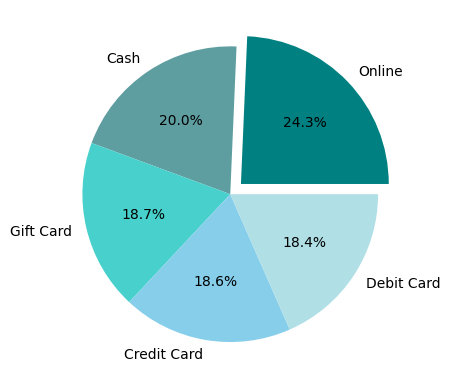

In [118]:
plt.pie(PaymentMethod_count.values, labels= PaymentMethod_count.index, autopct='%1.1f%%', explode=[0.1,0,0,0,0], colors =["teal", "cadetblue", "mediumturquoise", "skyblue", "powderblue",])
plt.show()

In [119]:
OrderStatus_count = data["OrderStatus"].value_counts()
OrderStatus_count.index


Index(['Cancelled', 'Returned', 'Pending', 'Delivered', 'Shipped'], dtype='object', name='OrderStatus')

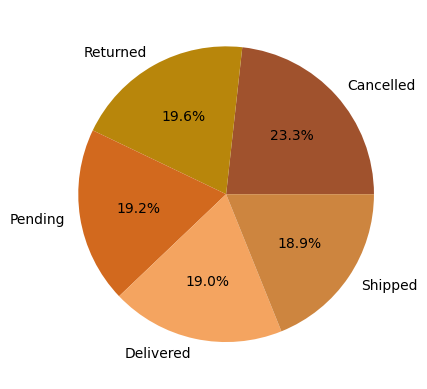

In [120]:
plt.pie(OrderStatus_count.values, labels= OrderStatus_count.index, autopct='%1.1f%%', colors =["sienna", "darkgoldenrod", "chocolate", "sandybrown", "peru"])
plt.show()

In [121]:
productCount = data ["Product"].value_counts()

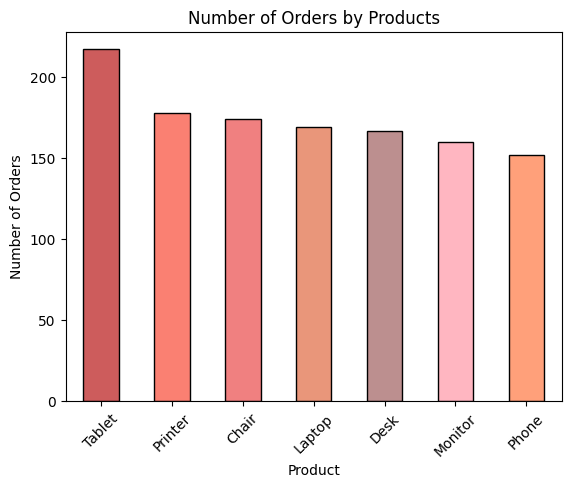

In [122]:
colors = ["indianred", "salmon", "lightcoral", "darksalmon", "rosybrown","lightpink", "lightsalmon"]
orders_by_product = data["Product"].value_counts()

orders_by_product.plot(kind="bar", color = colors, edgecolor = "black")
plt.title("Number of Orders by Products")
plt.xlabel("Product")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

## Conclusion

The dataset was successfully cleaned by handling missing values, removing duplicate records, correcting inconsistent entries, and standardizing the data. The cleaned dataset is now suitable for exploratory data analysis and future business insights.